In [26]:
import numpy as np, pandas as pd, scanpy as sc, matplotlib.pyplot as plt, os
from scipy.stats import hypergeom
import celloracle as co, glob, pickle
from functools import reduce
from tqdm import tqdm
import itertools, math, random
import networkx as nx

# visualization settings required to see plots in jupyter notebook
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

wd = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/grn_CO/female_type2'
feature_folder = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/slide_outs/optimize_slide/female_0.2_spec/0.01_0.5_out'
out_path = os.path.join(wd, 'lf_enrich')
os.makedirs(f"{out_path}/figures", exist_ok=True)
os.makedirs(f"{out_path}/out_files", exist_ok=True)
os.makedirs(f"{out_path}/out_files/SLIDE_LF_enrichment", exist_ok=True)
sc.settings.figdir = f"{out_path}/figures"
random.seed(42)

In [27]:
from utils import *

In [28]:
def fetch_GRN_data(oracle_object_name, GRN_wd):
    # Read oracle links after fitting
    oracle = co.load_hdf5(f"{GRN_wd}/out_files/{oracle_object_name}")
    GRN_network_scores = pd.read_csv(f"{GRN_wd}/out_files/ridge_fitted_2_merged_network_scores.csv", index_col=0)
    GRN_TFs = oracle.all_regulatory_genes_in_TFdict
    GRN_links_after_fit = {key: [] for key in oracle.coef_matrix_per_cluster.keys()}
    for cluster in oracle.coef_matrix_per_cluster.keys():
        cluster_specific_links = oracle.coef_matrix_per_cluster[cluster].stack().reset_index()
        cluster_specific_links.columns = ['source', 'target', 'coef_mean']
        cluster_specific_links = cluster_specific_links[cluster_specific_links ['coef_mean'] != 0].reset_index(drop=True)
        cluster_specific_links['coef_abs'] = np.abs(cluster_specific_links['coef_mean'])
        GRN_links_after_fit[cluster] = cluster_specific_links
        # links_after_fit[cluster]['weight'] = links_after_fit[cluster]['coef_abs'] * links_after_fit[cluster]['-logp']
        # GRN_TFs = GRN_TFs + list(links_after_fit[cluster].source.unique())
    return GRN_links_after_fit, GRN_network_scores, GRN_TFs

In [29]:
def read_slide_data(feature_folder, experiment):
    # Read SLIDE data for the experiment
    feature_files = glob.glob(f"{feature_folder}/*feature_list*")
    if experiment == 'male_type2':
        feature_data = [pd.read_csv(file, sep='\t', header=0) for file in feature_files if 'Z15' in file or 'Z29' in file]
    elif experiment == 'female_type2':
        feature_data = [pd.read_csv(file, sep='\t', header = 0) for file in feature_files if 'Z15' in file or 'Z38' in file or 'Z42' in file or 'Z55' in file]
    feature_data = pd.concat(feature_data)
    slide_features = set(feature_data['names'])
    return slide_features

In [31]:
# settings for enrichment analysis
input_dict = {
    'experiment': ['male_type2', 'female_type2'], # list of experiment names
    'slide_starting_genes': [1296, 1323], # number of starting genes in SLIDE
    'clusters_of_interest': [['KO','WT'], ['KO','WT']], # list of lists of clusters
    'order_fr_clust': [[2], [2]], # list of lists of cluster combination orders: 2 means combinations of 2 clusters
    'order_fr_tfcomb': [[1], [1]], # list of lists of TF combination orders: 1 means single TF
    'weight': ['strength', 'strength'],
}
input_df = pd.DataFrame(input_dict)

In [32]:
#### Assign the input parameters
#### You can change the index to 0 or 1 to run for different experiments
#### Or just loop over the dataframe rows
i=1
experiment = input_df['experiment'][i]
slide_starting_genes = input_df['slide_starting_genes'][i]
clusters_of_interest = input_df['clusters_of_interest'][i]
order_fr_clust = input_df['order_fr_clust'][i]
order_fr_tfcomb = input_df['order_fr_tfcomb'][i]
weight = input_df['weight'][i]

In [33]:
# ------------------------------------------------------------
# Reading the data
# ------------------------------------------------------------
#Read the GRN data and slide features
GRN_wd = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/grn_CO/female_type2'
oracle_object_name = 'female_type2_fitted.celloracle.oracle'
GRN_links_after_fit, GRN_network_scores, GRN_TFs = fetch_GRN_data(oracle_object_name, GRN_wd)
slide_features = read_slide_data(feature_folder, experiment)
cluster_fusions = []
for ord_clus in order_fr_clust:
    cluster_fusions += list(itertools.combinations(clusters_of_interest, ord_clus))

2026-01-29 12:14:48,088 - INFO - TemporaryDirectory.cleanup() worked.
2026-01-29 12:14:48,089 - INFO - shutil.rmtree worked.


In [50]:
create_df_pickle = True
for cluster_fusion in cluster_fusions:
    combined_links, threshold = create_combined_links_for_cluster_fusion(out_path, cluster_fusion, GRN_links_after_fit, quantile=0.90)
    grn, edges_df = filter_combined_links_and_build_grn(combined_links, threshold)

    fig = edges_df.groupby(['strength', 'key']).size().unstack().plot(kind='bar', stacked=True)
    plt.xlabel('Strength')
    plt.ylabel('Count')
    plt.title('Distribution of Key and Strength')
    plt.savefig(f"{out_path}/figures/combined_links_key_strength_{cluster_fusion}{experiment}.pdf")
    plt.close()
    # ------------------------------------------------------------
    # Creating the TF lists
    # ------------------------------------------------------------
    # Step1: Filter SLIDE data wrt GRN, since SLIDE and CO gene sets are not same
    slide_features = slide_features.intersection(set(grn.nodes)) 
    slide_features_neighbors = []
    for gene in slide_features:
        slide_features_neighbors += list(grn.predecessors(gene))
    slide_tot_TF = (slide_features.union(set(slide_features_neighbors))).intersection(GRN_TFs)

    # # Step2: Creating the list of network and random TFs only for analysis for order of TF combinations >1
    # # Read network scores
    # combined_network_scores = filter_network_score_data(cluster_fusion, GRN_network_scores)
    # combined_network_scores = combined_network_scores[combined_network_scores.index.isin(list(grn.nodes))] # Since SLIDE and CO gene sets are not same
    # combined_network_scores = combined_network_scores[combined_network_scores.index.isin(GRN_TFs)] # Since I want to pick size matched set of TFs only
    # #### Choosing size matched set of TFs from network and random
    # net_match_TF = set(combined_network_scores.index[:len(slide_tot_TF)])
    # # net_rnd_TF = set(random.sample(set(GRN_TFs).intersection(set(grn.nodes)), len(slide_tot_TF)))
    # net_rnd_TF = set(random.sample(set(GRN_TFs), len(slide_tot_TF)))

    # # write the TFs to file as separate csvs
    # pd.DataFrame(slide_tot_TF).to_csv(f"{out_path}/out_files/SLIDE_LF_{cluster_fusion}_{experiment}.csv", index=False)
    # pd.DataFrame(net_match_TF).to_csv(f"{out_path}/out_files/Net_match_{cluster_fusion}_{experiment}.csv", index=False)
    # pd.DataFrame(net_rnd_TF).to_csv(f"{out_path}/out_files/Net_rnd_{cluster_fusion}_{experiment}.csv", index=False)
    # # Create a Venn diagram for the three sets
    # from matplotlib_venn import venn3
    # venn = venn3([slide_tot_TF, set(net_match_TF), set(net_rnd_TF)], ('Slide', 'Net', 'Random'))
    # plt.show()


    # ------------------------------------------------------------
    # Finally doing enrichments
    # ------------------------------------------------------------
    for ord_tf in order_fr_tfcomb:
        cc_dict = {} # Initialize the dictionary to store enrichment results for each cluster fusion and order of TF combinations
        # Step1: Deciding TF combinations for which the enrichment needs to be done
        if ord_tf == 1:
            cases = [(slide_tot_TF, 'slide')]
        elif ord_tf == 2:
            # common_TFs = slide_tot_TF.intersection(net_match_TF.intersection(net_rnd_TF)) 
            # slide_tot_TF = slide_tot_TF- common_TFs
            # net_match_TF = net_match_TF - common_TFs
            # net_rnd_TF = net_rnd_TF - common_TFs
            cases = [(slide_tot_TF, 'slide')] #[(slide_tot_TF, 'slide'),(net_match_TF, 'net'),(net_rnd_TF, 'rnd')]
        # Step2: Performing enrichment analysis
        for TFs, case in cases:
            print(f"Running enrichment for {experiment}, {cluster_fusion}, {ord_tf} TFs, case = {case}")
            cc_dict = get_SLIDE_GRN_enrichment(edges_df,cc_dict,cluster_fusion,ord_tf,slide_features,slide_starting_genes,TFs,case)
        # ------------------------------------------------------------
        # Optionally generating the dataframe to be saved
        # ------------------------------------------------------------
        if create_df_pickle == True:
            suffix = f"_{experiment}"
            print(f"Creating enrichment dataframe for {experiment}, {cluster_fusion}, {ord_tf} TFs, all cases")
            enrichment_df= create_enrichment_df(out_path, cc_dict, cluster_fusion, ord_tf, filter = None, suffix=suffix)
            print(enrichment_df['case'].value_counts())
            # dumping the dictionary to pickle file
            with open(f"{out_path}/out_files/SLIDE_LF_enrichment/cc_dict_{ord_tf}_TFs_{cluster_fusion}{suffix}.pickle", 'wb') as f:
                pickle.dump(cc_dict, f)

2026-01-29 12:19:27,932 - INFO - TemporaryDirectory.cleanup() worked.
2026-01-29 12:19:27,932 - INFO - shutil.rmtree worked.


Threshold for edge strength: 0.13330834518230456
strong edges count: 0    18000
1     2000
Name: strength, dtype: int64
Running enrichment for female_type2, ('KO', 'WT'), 1 TFs, case = slide


100%|██████████| 78/78 [00:02<00:00, 32.64it/s]


Creating enrichment dataframe for female_type2, ('KO', 'WT'), 1 TFs, all cases
slide    15
Name: case, dtype: int64


# Plotting enrichment scores per cluster

In [51]:
import pickle
cluster_fusion = ('KO','WT')
experiment = 'female_type2'
ord_tf = 1
suffix = f"_{experiment}"
with open(f"{out_path}/out_files/SLIDE_LF_enrichment/cc_dict_{ord_tf}_TFs_{cluster_fusion}{suffix}.pickle", "rb") as f:
    cc_dict = pickle.load(f)

In [52]:
concatenated_df = pd.DataFrame()
for i in range(len(cc_dict[cluster_fusion][ord_tf])):
    used_weight_df = cc_dict[cluster_fusion][ord_tf][i][5][1]
    if used_weight_df.empty:
        continue
    used_weight_df['case'] = cc_dict[cluster_fusion][ord_tf][i][4]
    concatenated_df = pd.concat([concatenated_df, used_weight_df], ignore_index=True)
concatenated_df.to_csv(f"{out_path}/out_files/SLIDE_LF_enrichment/{ord_tf}_TFs_{cluster_fusion}{suffix}_used_weights.csv", index=False)

In [53]:
import ast
slide_lf_enriched = pd.read_csv(f"{out_path}/out_files/SLIDE_LF_enrichment/enriched_df_{ord_tf}_TFs_{cluster_fusion}{suffix}.csv")
used_weight_df = pd.read_csv(f"{out_path}/out_files/SLIDE_LF_enrichment/{ord_tf}_TFs_{cluster_fusion}{suffix}_used_weights.csv")
slide_lf_enriched = slide_lf_enriched[slide_lf_enriched['case']=='slide']
used_weight_df = used_weight_df[used_weight_df['case']=='slide']

slide_lf_enriched = slide_lf_enriched[['TF', 'common']]
slide_lf_enriched['TF'] = slide_lf_enriched['TF'].apply(ast.literal_eval).apply(tuple)
slide_lf_enriched['common'] = slide_lf_enriched['common'].apply(ast.literal_eval).apply(list)
slide_lf_enriched = slide_lf_enriched.explode('common')
slide_lf_enriched = slide_lf_enriched.explode('TF')
slide_lf_enriched.columns = ['source', 'target']
used_weight_df = used_weight_df[used_weight_df['case']=='slide']
used_weight_df = used_weight_df[used_weight_df['strength']==1]
slide_lf_enriched = slide_lf_enriched.merge(used_weight_df, on=['source', 'target'], how='left')
slide_lf_enriched.to_csv(f"{out_path}/out_files/SLIDE_LF_enrichment/enriched_df_{ord_tf}_TFs_{cluster_fusion}{suffix}_used_weights_strong.csv", index=False)

In [54]:
fig = slide_lf_enriched.groupby(['strength', 'key']).size().unstack().plot(kind='bar', stacked=True)
# fig = slide_lf_enriched.groupby(['strength', 'key']).plot(kind='bar', stacked=True)
plt.xlabel('Strength')
plt.ylabel('Count')
plt.title('Distribution of Key and Strength')
plt.savefig(f"{out_path}/figures/enriched_key_strength_{ord_tf}_TFs_{cluster_fusion}{suffix}_used_weights_strong.pdf")
plt.close()

In [55]:
def read_slide_data_2(feature_folder, experiment):
    feature_files = glob.glob(f"{feature_folder}/*feature_list*")
    if experiment == 'male_type2':
        feature_data = [pd.read_csv(file, sep='\t', header=0) for file in feature_files if 'Z15' in file or 'Z29' in file]
    elif experiment == 'female_type2':
        feature_data = [pd.read_csv(file, sep='\t', header = 0) for file in feature_files if 'Z15' in file or 'Z38' in file or 'Z42' in file or 'Z55' in file]
    feature_data_df = pd.concat(feature_data)
    positive_corr_names = set(feature_data_df[feature_data_df['corrs'] >= 0]['names'])
    negative_corr_names = set(feature_data_df[feature_data_df['corrs'] < 0]['names'])
    return positive_corr_names, negative_corr_names


positive_corr_names, negative_corr_names = read_slide_data_2(feature_folder, experiment)

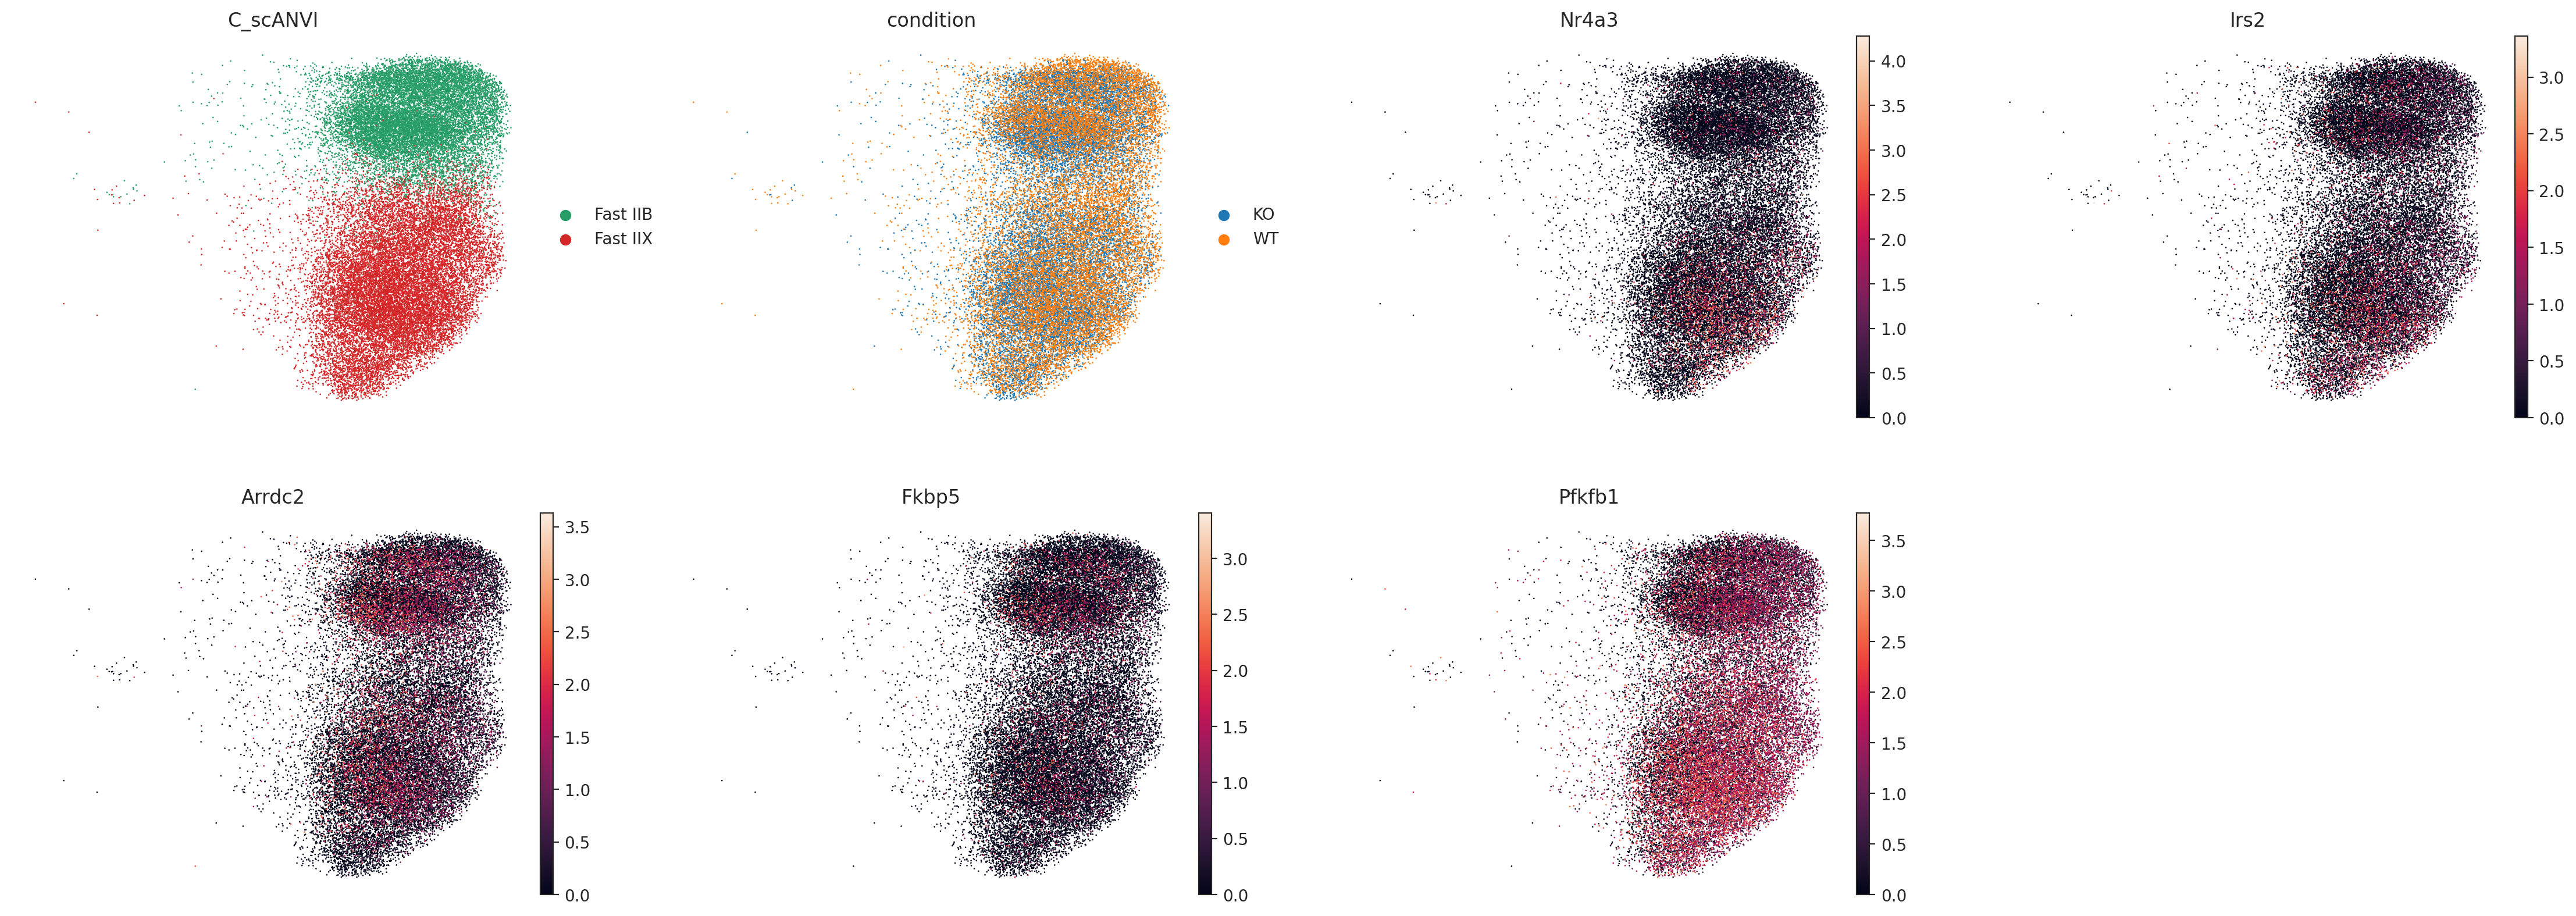

In [56]:
path_to_adata = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/female_adata_stream_input.h5ad'
adata = sc.read_h5ad(path_to_adata)
#sc.pl.umap(adata=adata, color=['C_scANVI','condition','Pdk4', 'Ucp3', 'Kcnip1', 'Sntb1', 'Abra'], frameon=False,)
sc.pl.umap(adata=adata, color=['C_scANVI','condition','Nr4a3', 'Irs2', 'Arrdc2', 'Fkbp5', 'Pfkfb1'], frameon=False,)

In [57]:
import plotly.express as px
import pandas as pd

# Compute color proportions per TF
slide_lf_enriched['color'] = slide_lf_enriched['target'].apply(lambda gene: 'red' if gene in positive_corr_names else ('blue' if gene in negative_corr_names else 'gray'))
color_histcounts = slide_lf_enriched.groupby('source')['color'].value_counts(normalize=True).unstack(fill_value=0)

# Initialize score map
tf_name_score = {key: None for key in color_histcounts.index.values}

# Fill score map
for entry in cc_dict[cluster_fusion][ord_tf]:
    tf, cond, score_val = entry[0][0], entry[1], entry[2][0]
    if tf in tf_name_score and cond == (1,):
        tf_name_score[tf] = score_val

# Filter and sort by score
sorted_data = sorted(
    [(v, k) for k, v in tf_name_score.items() if v is not None],
    reverse=True,
    key=lambda x: x[0]
)
if not sorted_data:
    raise ValueError("No valid TF scores found for plotting.")

score, tf_name = zip(*sorted_data)
score_series = pd.Series(score, index=tf_name, name='score')

# Subset color proportions in sorted TF order
color_proportions = color_histcounts.loc[list(tf_name)]

# Save original proportions for annotation
original_props = color_proportions.copy()

# Scale each color proportion by the score (so bar height = score)
scaled = color_proportions.mul(score_series, axis=0).reset_index()
scaled = scaled.rename(columns={'index': 'source'})

# Melt both DataFrames
melted_scaled = scaled.melt(id_vars='source', var_name='color', value_name='height')
melted_props = original_props.reset_index().melt(id_vars='source', var_name='color', value_name='proportion')

# Merge both for text labels
plot_df = melted_scaled.merge(melted_props, on=['source', 'color'])

# Format the text as percentages
plot_df['text'] = (plot_df['proportion'] * 100).round(1).astype(str) + '%'

# Plot
fig = px.bar(
    plot_df,
    x='source',
    y='height',
    color='color',
    text='text',  # <- Add text here
    labels={'height': 'Score-scaled Proportion', 'source': 'TF'},
    title=f'TF Enrichment Scores with color Proportions for {experiment} - {cluster_fusion} - {ord_tf} Order'
)

# Improve text visibility inside bars
fig.update_traces(textposition='inside', insidetextanchor='middle')

# Layout tweaks
fig.update_layout(
    xaxis_title='Transcription Factor (TF)',
    yaxis_title='Enrichment Score',
    xaxis_tickangle=-90,
    font=dict(family="Arial", size=8, color="black"),
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, showline=True, linecolor='black', ticks='outside'),
    yaxis=dict(showgrid=False, showline=True, linecolor='black', ticks='outside')
)

fig.show()
fig.write_image(f"{out_path}/figures/0_9_TF_Enrichment_Scores_with_color_Proportions_{ord_tf}_TFs_{cluster_fusion}_{experiment}.svg", format='svg')

2026-01-29 12:19:47,662 - INFO - Chromium init'ed with kwargs {}
2026-01-29 12:19:47,663 - INFO - Found chromium path: /ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-01-29 12:19:47,664 - INFO - Temp directory created: /tmp/tmp2uchzrur.
2026-01-29 12:19:47,665 - INFO - Opening browser.
2026-01-29 12:19:47,666 - INFO - Temp directory created: /tmp/tmpjnx2_5b9.
2026-01-29 12:19:47,676 - INFO - Temporary directory at: /tmp/tmpjnx2_5b9
2026-01-29 12:19:47,971 - INFO - Conforming 1 to file:///tmp/tmp2uchzrur/index.html
2026-01-29 12:19:47,972 - INFO - Waiting on all navigates
2026-01-29 12:19:49,166 - INFO - All navigates done, putting them all in queue.
2026-01-29 12:19:49,167 - INFO - Getting tab from queue (has 1)
2026-01-29 12:19:49,168 - INFO - Got A0FF
2026-01-29 12:19:49,168 - INFO - Processing TF_Enrichment_Scores_with_color_Proportions_for_female_type2___KO_WT___1_Order.svg
2026-01-2